# UE ADSP

# Analogical and Digital Signal Processing
# for sensor data

## TP 2 : Estimation spectrale non paramétrique


### 1. But du TP 
Le but de ce TP consiste à manipuler des signaux à caractère aléatoire et plus spécialement à estimer la DSP (Densité́ Spectrale de Puissance). La fonction d’autocorrélation et sa transformée de Fourier sont de l’information déterministe, mais leur estimation se faisant à partir de réalisation de signaux aléatoires demeure une variable aléatoire. 
Le TP se décompose en plusieurs parties (autrement dit fonctions) à écrire en en Python. On pourra utiliser le notebook fourni qu’il faudra compléter.
Il s’agit, dans un premier temps de modéliser (générer) un signal aléatoire par filtrage d’un bruit blanc.
Si on utilise le bruit blanc gaussien discret $b(n)$ comme excitation d’un filtre linéaire discret, on peut ainsi imposer au signal de sortie $y(n)$ la DSP que l’on souhaite. 
En effet : 

$$\gamma_y (\nu)=|H(\nu)|^2 \gamma_b (\nu)=|H(\nu)|^2 \sigma_b^2=|H(\nu)|^2 N_0$$
avec
$$y(n)=(h*b)(n)$$
- $h(n)$ : réponse impulsionnelle du filtre
- $H(\nu)$ : réponse fréquencielle
- $b(n)$ : bruit blanc gaussien (entrée)
- $y(n)$ : sortie du filtre
  
Il s’agit, ensuite, de vérifier que la forme théorique de la DSP de sortie ($\gamma_y (\nu)$) peut être estimée par l’intermédiaire de deux méthodes d’analyse spectrale : le périodogramme et le corrélogramme. 
Nous utiliserons finalement la génération d’un signal sinusoïdal afin, après l’avoir bruité, de retrouver ses caractéristiques (toujours par analyse spectrale).

- 2.1. Création du signal avec une DSP connue et affichage de la DSP théorique.
  - 2.1.1. Création d'un bruit blanc gausssien
  - 2.1.2. Définir le signal ayant une DSP connue
  - 2.1.3. Création de la DSP théorique
- 2.2. Estimation de la DSP
   - 2.2.1. Periodogramme
   - 2.2.2. Corrélogramme
   - 2.2.3. Méthode de Welch
   - 2.2.4. Méthode de Bartlett
- 2.3. Estimation de la moyenne et de la variance de chaque estimateur 
- 2.4. Test sur un signal contenant 3 sinus.

# 2. TP

## 2.1. Création du signal avec une DSP connue et affichage de la DSP théorique.

- Création du signal
- Création de la DSP théorique

- Importation des librairies python

In [112]:
import dateutil.parser
from dateutil.parser import parse 
import pandas as pd  # This is always assumed but is included here as an introduction.
import numpy as np
import matplotlib.pyplot as plt
from pandas import Series

from pandas.plotting import autocorrelation_plot
from pandas.plotting import register_matplotlib_converters
import scipy
from scipy import signal


# frequence echantillonnage
fs = 1

### 2.1.1 Création de la fonction *Initbruit*

Cette fonction permet la génération d'un bruit blanc gaussien

- input
    - NbPoints : nbre de points
    - sigma : Ecart type du bruit blanc
- output
    - bruit : signal (contenant le bruit)


utilisation de la fonction [*numpy.random.normal*](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html)

In [113]:
def Initbruit(NbPoints: int, sigma: float) -> np.ndarray:
    mu = 0.0
    np.random.seed(0)
    bruit = np.random.normal(mu, sigma, NbPoints)

    return bruit

- Création et affichage du bruit

  - Le nombre de points est égal à 1000
  - L'ecart type du bruit est égal à 1.0  

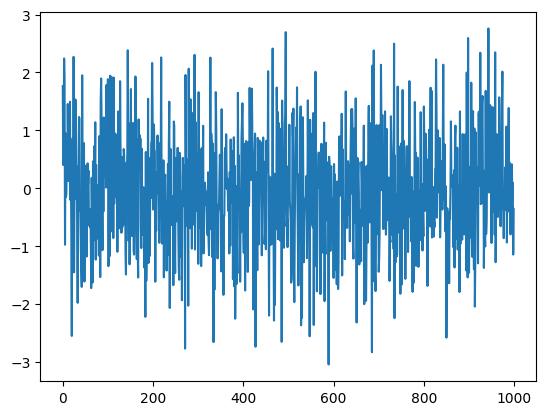

In [114]:
NbPoints = 1_000
ecarttype = 1.0

bruit = Initbruit(NbPoints, ecarttype)

plt.plot(bruit)

### 2.1.2 Création de la fonction *Initsignal*

Filtrage d'un signal par un filtre récursif RII (Réponse Impulsionnelle Infinie).

$$y(n)=-\sum_{j=1}^p{a_jy(n-j)}+\sum_{i=0}^q{b_i bruit(n-i)}$$

filtrage d'un signal par un filtre recursif 
- input
  - bruit : signal d'entrée
  - b : coefficient du numérateur
  - a : coefficient du dénominateur

- output
  - signal : signal filtré

utilisation de la fonction [*signal.lfilter*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)

In [115]:
def Initsignal(bruit : np.ndarray, b : list, a : list) -> np.ndarray:
    signal = scipy.signal.lfilter(b, a, bruit, axis=-1, zi=None)
    
    return signal

- Définir les coefficients du filtre récursif.

- Filtrer le bruit défini en 2.1.1 puis afficher le résultat

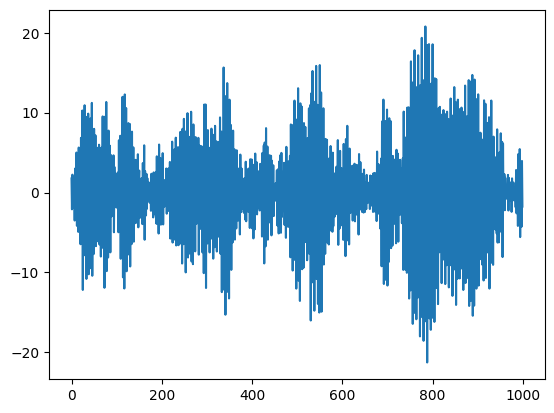

In [116]:
# denominateur
a = [1.0,  1.42, 0.981]
# numerateur
b = [1.]

signalb = Initsignal(bruit, b , a)

plt.plot(signalb)

In [117]:
# Affichage des coefficients des filtres
print("a :",a, " ; b :",b)

a : [1.0, 1.42, 0.981]  ; b : [1.0]


### 2.1.3 Création de la fonction *Gainfiltre* - et de la DSP théorique

Filtrage d'un signal par un filtre IIR.

$$H(z)=\frac{\sum_{i=0}^q{b_i}z^{-i}}{1+\sum_{j=1}^p{a_jz^{-j}}}=\frac{\sum_{i=0}^q{b_i}z^{-i}}{\sum_{j=0}^p{a_jz^{-j}}}$$
avec $b_0=1$

$$H(\nu)=H(z)|_{z=e^{j2\pi \nu /f_e}}$$

gain du filtre entre $-F_e/2$ et $F_e/2$.

- input
  - b, a : coefficients du filtre
  - N : nbre de points

- output
  - w : fréquence
  - h : reponse frequentielle 


 Utilisation de la fonction [*signal.freqz*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.freqz.html) en sortie on indique les fréquences et la réponse fréquentielle

- Affichage du spectre théorique de $y(n)$ (module en dB).

In [118]:
def Gainfiltre(a : list, b : list, N : int, fs: float) -> np.ndarray | np.ndarray:
    w, h = scipy.signal.freqz(b,a, worN=N, whole=True, fs = fs)
    
    return w, h

Text(0, 0.5, 'Amplitude (dB)')

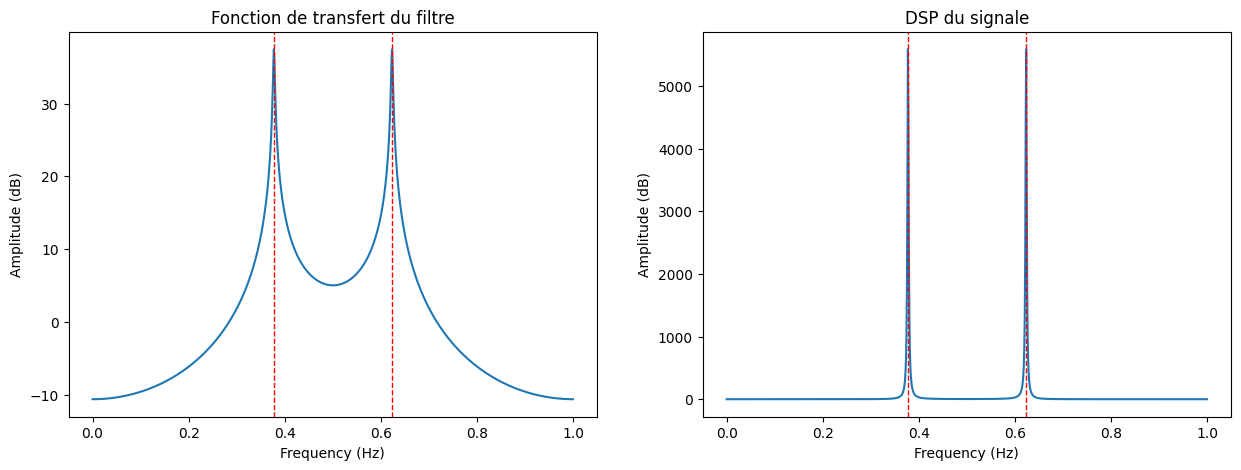

In [119]:
w, h = Gainfiltre(a, b, NbPoints, fs)
peak_value_1, peak_value_2 = w[np.argpartition(h, -2)[-2:]]

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(w, 20*np.log10(np.abs(h)))
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1)
plt.title("Fonction de transfert du filtre")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.plot((w), np.abs(h)**2*ecarttype**2)
plt.title("DSP du signale")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


- Décrire et commenter le résultat obtenu (en fonction du filtre choisi).

En considerans la fonction de transfert du filtre, on observe que le filtre atténue le signale sauf autour des deux fréquence 0.622, 0.378 c'est le comportement d’un filtre résonant (passe-bande double) avec des poles en ces deux fréquences. 

En ce qui concerne la dsp du signale à la sortie du filtre en remarque bien que l'energie et répartie justement sur ces deux fréquence le filtre agit donc comme prévu : il met en valeur ces fréquences. 

## 2.2 Estimateur

### 2.2.1 Calcul du periodogramme

- On programme la fonction du periodogram

$$\hat{\gamma}_{perio}(k)=\frac{1}{\Gamma_g(0)}|Y(k)|^2$$

$Y(k)$ est la FFT de $y(n)$

Affichage du résultat (en dB) - comparaison avec le résultat obtenu avec [*scipy.signal.periodogram*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html) 

[*numpy.fft*](https://numpy.org/doc/2.1/reference/routines.fft.html#module-numpy.fft) indique les différentes fonctions utiles dans le cadre de la fft.

(attention, le spectre doit s'afficher entre $-F_e/2$ et $F_e/2$ et à la normalisation)

- input
  - signalb : signal dont on calcule le periodogramme
  - fs : frequence d'échantillonnage

- output
  - w : frequence 
  - periodogram : le periodogramme (en module)

In [120]:
def Periodogram(signalb, fs = fs):
    
    #periodogram = scipy.signal.periodogram(signalb, fs, return_onesided=False)
    
    Pxx_den = np.abs(np.fft.fftshift(np.fft.fft(signalb)))**2 / (NbPoints)
    f = np.fft.fftshift(np.fft.fftfreq(NbPoints, 1/fs))
    
    return f, Pxx_den

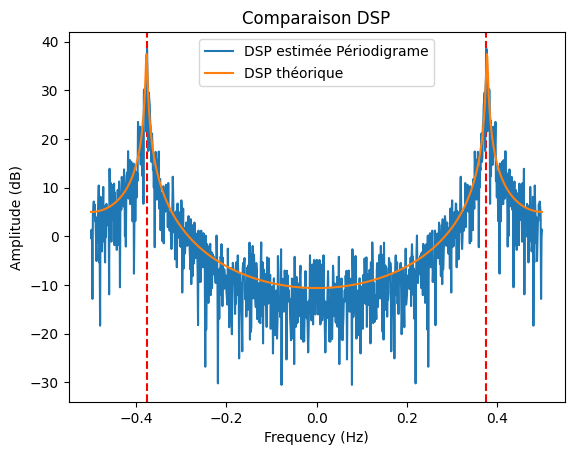

In [121]:
f, Pxx_den = Periodogram(signalb, fs)

peak_value_1, peak_value_2 = f[np.argpartition(Pxx_den, -2)[-2:]]

plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot(f, 10*np.log10(Pxx_den), label="DSP estimée Périodigrame")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title("Comparaison DSP")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.legend()

- Calcul du periodogramme en utilisant la définition précédente et affichage du résultat (en dB et en module)

- Comparaison du résultat précédent avec le résultat obtenu par la fonction *scipy.signal.periodogram*


In [122]:
dsp_ = np.fft.fftshift(scipy.signal.periodogram(signalb, fs, return_onesided=False)[1])
print(f"L'erreur quadratique moyenne entre le periodigramme et scipy.signal.periodigram est de {np.mean((Pxx_den - dsp_)**2)}")

L'erreur quadratique moyenne entre le periodigramme et scipy.signal.periodigram est de 3.234126541273571e-05


- Décrire, analyser et commenter le résultat obtenu en fonction du gain théorique

Le périodogramme fournit une estimation non biaisée de la DSP, ce qui se vérifie par la bonne localisation des pics spectraux. 

Cependant, il n’est pas consistant : sa variance reste élevée même pour de grandes tailles d’échantillon. Cela se traduit par des fluctuations importantes autour de la DSP théorique. Les résultats observés illustrent ce comportement : l’estimateur suit correctement l’enveloppe spectrale globale mais présente de fortes oscillations locales, en particulier dans les zones de faible puissance.

### 2.2.2 Calcul du correlogramme

$\hat{\gamma}_{corr}(k)$ correspond à la FFT de l'estimation de la fonction d'auto-corrélation.

On estime $\hat{\Gamma}_{corr}(k)$ pour une valeur de $\tau$ comprise entre $-maxlags$ et $maxlags$.

$\hat{\gamma}_{corr}(k)=FFT(\hat{\Gamma}_{corr}(k))$ en effectuant du zero padding pour avoir une estimation de la DSP de même longueur que le signal.

utiliser [*scipy.signal.correlate*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate.html) et [*scipy.signal.correlation_lags*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlation_lags.html) pour calculer les coefficients de correlation.

- input
  - signalb : signal dont on calcule le correlogramme
  - fs : frequence d'échantillonnage
  - maxlags :
  - norm : 'biaised', 'unbiased'

- output
  - w : frequence 
  - corr : le correlogramme

In [123]:
def Correlogram(signalb, fs = fs, maxlags=600, norm=None):

    corr_ = signal.correlate(signalb, signalb, mode='full')
    coeff = signal.correlation_lags(len(signalb), len(signalb), mode='full')
    
    mask = np.abs(coeff) <= maxlags
    corr_filtered = corr_[mask]
    
    corr = np.zeros(NbPoints)
    
    corr[:maxlags] = corr_filtered[:maxlags]
    corr[-maxlags:] = corr_filtered[maxlags+1:]
    
    corr_fft = np.fft.fft(corr/NbPoints)
    w = np.fft.fftfreq(len(corr_fft), 1/fs)
    
    return np.fft.fftshift(w), np.fft.fftshift(corr_fft)

Calcul et affichage

Text(0, 0.5, 'Amplitude (dB)')

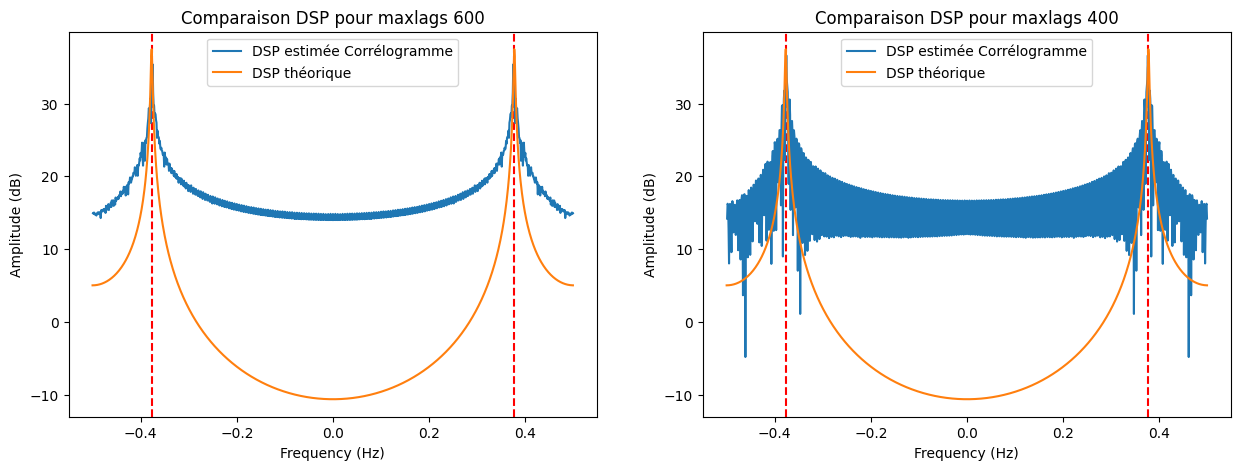

In [124]:
w, corr_1 = Correlogram(signalb, fs, maxlags=600)
w, corr_2 = Correlogram(signalb, fs, maxlags=400)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot(w[1:], 10*np.log10(np.abs(corr_1))[1:], label="DSP estimée Corrélogramme")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title(f"Comparaison DSP pour maxlags {600}")
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


plt.subplot(1,2,2)
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot(w[1:], 10*np.log10(np.abs(corr_2))[1:], label="DSP estimée Corrélogramme")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title(f"Comparaison DSP pour maxlags {400}")
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


- Décrire et analyser/expliquer le résultat obtenu (il est conseillé d'afficher les résultats avec  au moins deux valeurs de maxlags différentes, comparer avec le résultat théorique).

### Bias
La troncature de l’auto-corrélation à (|k| \le M) équivaut à une **fenêtrage temporel rectangulaire**, ce qui induit un biais spectral :

$
\mathbb{E}\left\{\hat{S}_{corr}(f)\right\}
= S(f) * W_M(f)
$

avec (W_M(f)) est la transformée de Fourier de la fenêtre rectangulaire (noyau de Dirichlet).

plus `maxlags` est grand, moins la DSP est lissée, meilleure est la résolution fréquentielle.



### Variance

La variance de l’estimation dépend du nombre effectif d’échantillons utilisés pour estimer chaque retard (k) :

$
\mathrm{Var}\left\{\hat{\Gamma}(k)\right\} \propto \frac{1}{N - |k|}
$

Ainsi, pour de grands retards ((|k| \approx M)) :

* peu d’échantillons contribuent,
* l’estimation devient instable.
plus `maxlags` est grand, plus de variance sur la DSP  moins bonne la résolaution. 

Le paramètre maxlags contrôle la troncature de l’auto-corrélation : une valeur faible produit une estimation de DSP stable mais fortement biaisée, tandis qu’une valeur élevée réduit le biais au prix d’une augmentation de la variance.

### 2.2.3 Periodogram lissé

On applique un filtre passe-bas sur le périodogramme.

On peut utiliser un moyenneur ou bien un filtre gaussien.

Filtre moyenneur de taille $M$ : 
- $h(i) = 1/M$ si $i\in[0,M-1]$
- $h(i)=0$ sinon

[*Filtre gaussien*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter1d.html)

Convolution : [np.convolve](https://numpy.org/doc/2.1/reference/generated/numpy.convolve.html)

In [125]:
def Periodogramlisse(signalb):
    filtre = np.ones(4) / 4 #scipy.ndimage.gaussian_filter1d([1.0, 2.0, 3.0, 4.0, 5.0], 1)
    periodogramlisse = np.convolve(signalb, filtre)
    
    return periodogramlisse

Calcul et affichage

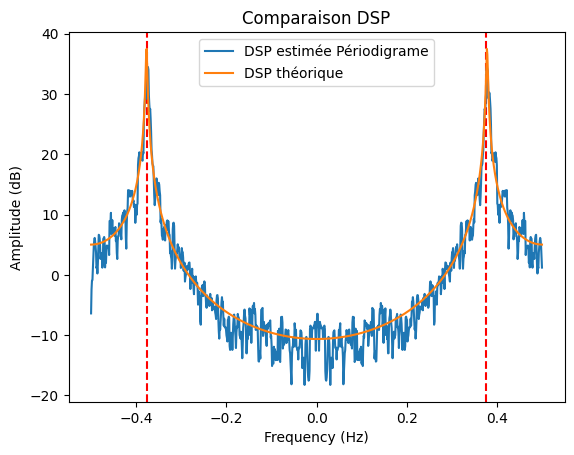

In [126]:
periodogramlisse = Periodogramlisse(Pxx_den)[:-3]

plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot(f, 10*np.log10(periodogramlisse), label="DSP estimée Périodigrame")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title("Comparaison DSP")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.legend()

- décrire, analyser et commenter

### Variance

Le périodogramme brut est un estimateur **asymptotiquement non biaisé**, mais à **variance élevée** :

$
\mathrm{Var}{\hat{S}_{per}(f)} \not\to 0 \quad \text{quand } N \to \infty
$

Le lissage revient à effectuer une moyenne locale :

$
\hat{S}_{liss}(f)
= \int \hat{S}_{per}(\nu), W(f-\nu), d\nu
$

où (W(f)) est la fenêtre de lissage.

L'effet est un spectre plus régulier et des pics spectraux mieux identifiables. Le lissage réduit la variance de l'estimation. 

### Biais de lissage

Le lissage introduit un biais car l’espérance devient :

$
\mathbb{E}{\hat{S}_{liss}(f)}
= S(f) * W(f)
$

On remarque un élargissement des pics fusion de raies proches surtout entre les dexu fréquence des pics. 

Dans le cas du périodogramme lissé, le lissage permet de réduire significativement la variance du périodogramme brut, au prix d’un biais spectral dû à la convolution par la fenêtre de lissage. Lorsque la fenêtre est correctement choisie, l’estimateur obtenu est plus fiable pour l’analyse globale du spectre.

### 2.2.4. Méthode Bartlett

La méthode de Bartlett consiste dans les étapes suivantes :

Le segment original est composé de N points. Il est divisé en K (sans chevauchement) sous-segments, chacun de taille M.

Pour chaque segment calculer le périodogramme en calculant la transformée de Fourier discrète. Ensuite. calculez le carré de la magnitude et diviser par M.

Faire la moyenne du résultat des périodogrammes au-dessus pour les K sous-segments.


In [127]:
def bartlett(signal, M = 500): 
    K = int(np.floor(NbPoints/M))
    estim_real = np.zeros((K, NbPoints))
    w = np.fft.fftfreq(NbPoints, 1/fs)

    for k in range(K):
        sig_pre_fft = (signal[k*M:(k+1)*M])
        sig_ = np.zeros(NbPoints)
        sig_[0:M//2] = sig_pre_fft[0:M//2]
        sig_[M//2:M] = sig_pre_fft[M//2:]
        fft_sig = np.fft.fft(sig_).reshape(-1)
        estim_real[k, :] = np.abs(fft_sig)
    return np.fft.fftshift(w), np.fft.fftshift(np.mean(estim_real, axis = 0))

Text(0, 0.5, 'Amplitude (dB)')

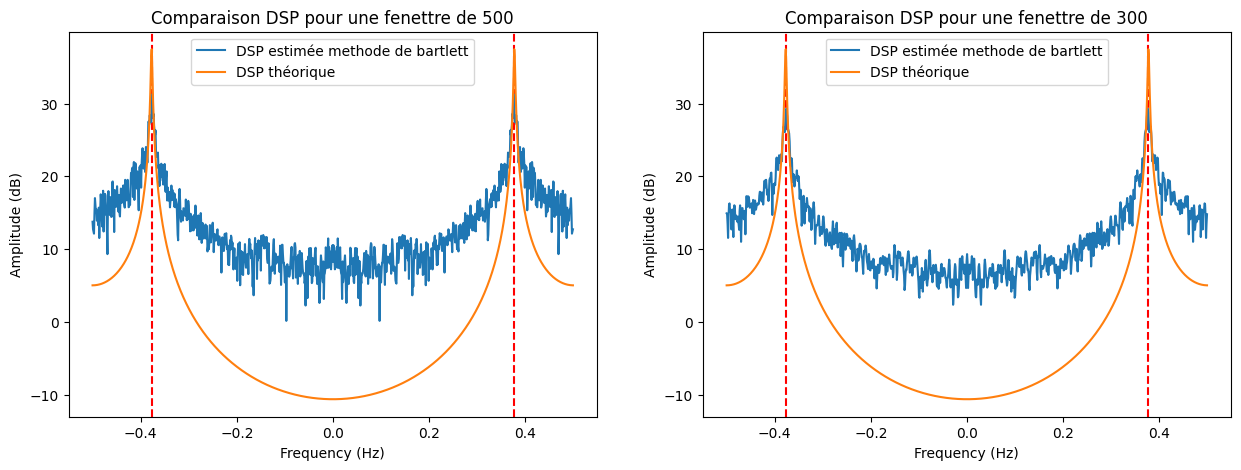

In [130]:
w, bartlett_dsp_1 = bartlett(signalb, M=500)
w, bartlett_dsp_2 = bartlett(signalb, M=300)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot((w), 10*np.log10((bartlett_dsp_1)), label="DSP estimée methode de bartlett")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title(f"Comparaison DSP pour une fenettre de {500}")
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot((w), 10*np.log10((bartlett_dsp_2)), label="DSP estimée methode de bartlett")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title(f"Comparaison DSP pour une fenettre de {300}")
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


- décrire et commenter

### Variance

La moyenne de (K) périodogrammes indépendants réduit la variance :

$
\mathrm{Var}\left\{\hat{S}*{B}(f)\right\}
\approx \frac{1}{K} \mathrm{Var}{\hat{S}_{per}(f)}
$

pour une valeur de K elevée la variacne est réduite. 



### Biais (résolution fréquentielle)

Chaque périodogramme est calculé sur un segment de longueur $L$. L’espérance de l’estimateur de Bartlett est :

$
\mathbb{E}\left\{  \hat{S}_{B}(f) \right\}
= S(f) * |W_L(f)|^2
$

où $W_L(f)$ est la transformée de Fourier de la fenêtre rectangulaire de longueur (L).


Comme la largeur du lobe principal $\propto \frac{1}{L}$ plus (L) est petit le **lissage spectral plus fort** et le bias qugmente. 

La méthode de Bartlett fournit une estimation de DSP plus stable que le périodogramme brut grâce au moyennage de segments. Cependant, la réduction de variance s’accompagne d’un biais de lissage dépendant de la longueur de fenêtre : des segments courts produisent un spectre plus régulier mais sous-estiment et élargissent les pics spectraux, tandis que des segments longs améliorent la résolution fréquentielle au prix d’une variance plus élevée.

### 2.2.5 Méthode de Welch

Le signal est d'abord décomposé en K fenêtres overlappées de taille M, multipliées, avant transformation, par une fenêtre de pondération (type Hamming, Hanning, Kaiser, ...) ou pas. 

La TF (créée sur Nb points) est ensuite moyennée. 


In [66]:
def welch(signal,  M = 500, O = 100): 
    K = int(np.floor((NbPoints - M)/(M - O)))
    estim_real = np.zeros((K, NbPoints))
    w = np.fft.fftfreq(NbPoints, 1/fs)

    for k in range(K):
        sig_pre_fft = (signal[k*(M-O):k*(M-O) + M])
        sig_ = np.zeros(NbPoints)
        sig_[0:M//2] = sig_pre_fft[0:M//2]
        sig_[M//2:M] = sig_pre_fft[M//2:]
        fft_sig = np.fft.fft(sig_).reshape(-1)

        estim_real[k, :] = np.abs(fft_sig)
    
    return np.fft.fftshift(w), np.fft.fftshift(np.mean(estim_real, axis = 0))

Text(0, 0.5, 'Amplitude (dB)')

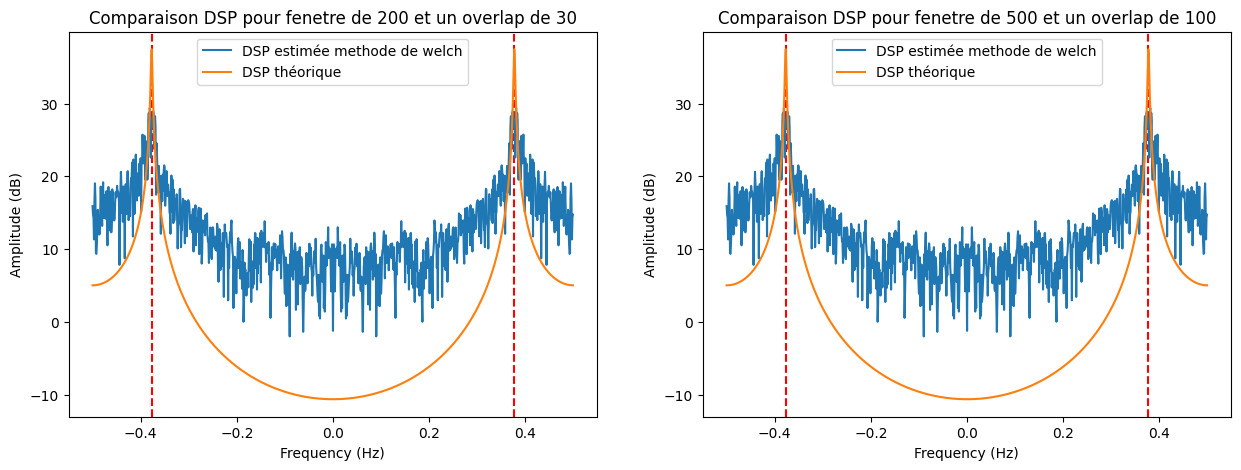

In [134]:
w, welch_dsp_1 = welch(signalb, M=500, O=50)
w, welch_dsp_2 = welch(signalb, M=500, O=100)


plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot((w), 10*np.log10((welch_dsp_1)), label="DSP estimée methode de welch")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title(f"Comparaison DSP pour fenetre de {200} et un overlap de {30}")
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)

plt.plot((w), 10*np.log10((welch_dsp_2)), label="DSP estimée methode de welch")
plt.plot(f, 10*np.log10(np.abs(np.fft.fftshift(h))**2*ecarttype**2), label="DSP théorique")
plt.title(f"Comparaison DSP pour fenetre de {500} et un overlap de {100}")
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


- Décrire, analyser et commenter les résultats obtenus.

### Variance

La moyenne de (K) périodogrammes indépendants réduit la variance :

$
\mathrm{Var}\left\{\hat{S}*{B}(f)\right\}
\approx \frac{1}{K} \mathrm{Var}{\hat{S}_{per}(f)}
$

pour une valeur de K elevée la variacne est réduite.  Le recouvrement n’améliore pas la résolution fréquentielle. Il réduit la variance de l’estimation, mais de façon très limitée.

### Biais (résolution fréquentielle)

Chaque périodogramme est calculé sur un segment de longueur $L$. L’espérance de l’estimateur de Bartlett est :

$
\mathbb{E}\left\{  \hat{S}_{B}(f) \right\}
= S(f) * |W_L(f)|^2
$

où $W_L(f)$ est la transformée de Fourier de la fenêtre rectangulaire de longueur (L).


Comme la largeur du lobe principal $\propto \frac{1}{L}$ plus (L) est petit le **lissage spectral plus fort** et le bias qugmente. 



La méthode de Bartlett fournit une estimation de DSP plus stable que le périodogramme brut grâce au moyennage de segments. Le recouvrement n’améliore pas la résolution fréquentielle. Il réduit la variance de l’estimation, mais de façon très limitée. Cependant, la réduction de variance s’accompagne d’un biais de lissage dépendant de la longueur de fenêtre : des segments courts produisent un spectre plus régulier mais sous-estiment et élargissent les pics spectraux, tandis que des segments longs améliorent la résolution fréquentielle au prix d’une variance plus élevée.

## 2.3 Estimation des variances de chaque estimateur

- en boucle
  - générer un signal de bruit
  - le filtrer
  - calculer les DSP (en les stockant dans des tableaux différents de taille (nbreitération, nbpoints))
    
- calculer les moyennes (*numpy.mean*, attention à l'axe axis=0) et les variances (*numpy.var*) pour chaque fréquences pour chaque estimateur
  - pour chaque estimateur
    - afficher l'estimation de la moyenne de l'estimateur 
    - afficher l'estimation de l'écartype 
    - afficher le gain théorique (on pourra en déduire le biais)

In [135]:
def mean_var(estimateur, signal, nbrIteration = 1_000):
    DSPs = np.zeros((nbrIteration, NbPoints))
    for n in range(nbrIteration): 
        w, DSP = estimateur(signal)
        DSPs[n, :] = np.abs(DSP)
    
    mean = DSPs.mean(axis = 0)
    var = ((DSPs - mean)**2).mean(axis = 0)
    return mean, var

Text(0, 0.5, 'Amplitude (dB)')

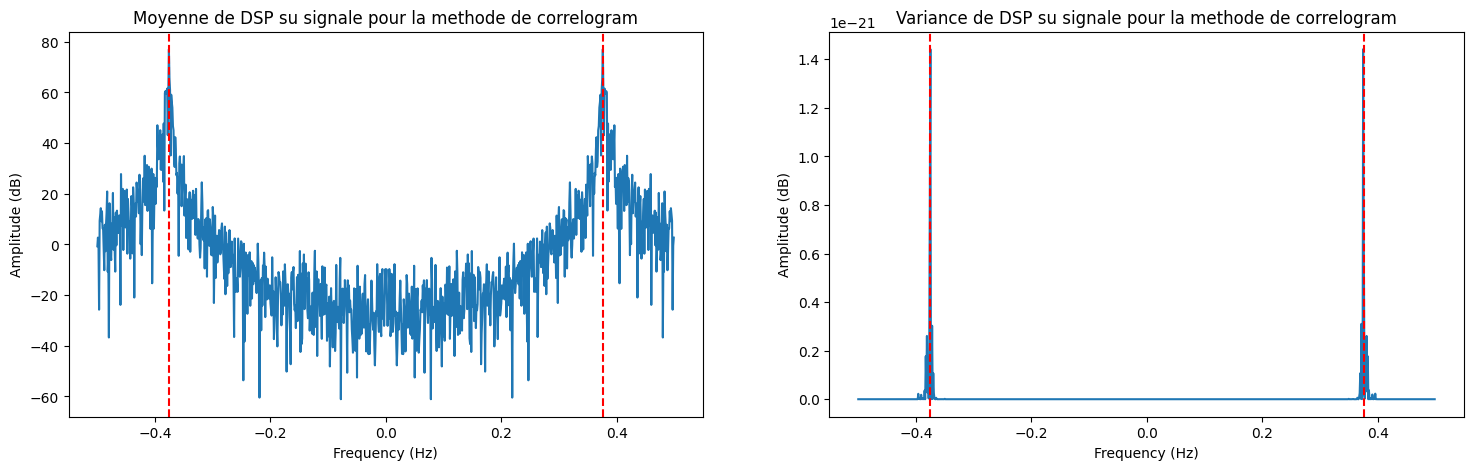

In [136]:
mean, var = mean_var(Periodogram, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot((w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de correlogram")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.plot((w), var)
plt.title("Variance de DSP su signale pour la methode de correlogram")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


Text(0, 0.5, 'Amplitude (dB)')

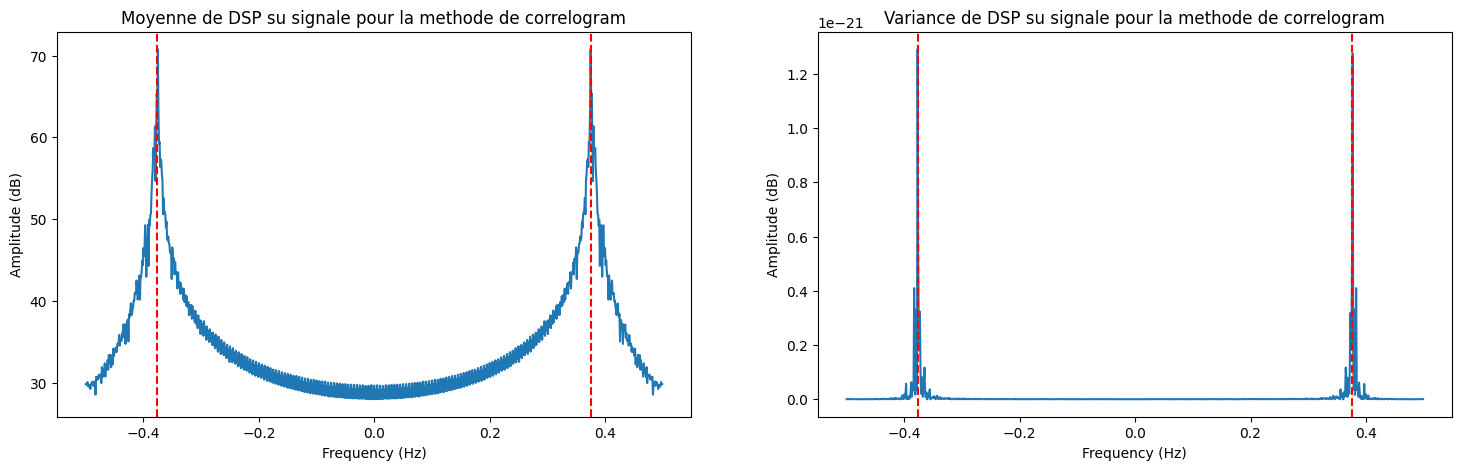

In [137]:
mean, var = mean_var(Correlogram, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot((w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de correlogram")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.plot((w), var)
plt.title("Variance de DSP su signale pour la methode de correlogram")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


Text(0, 0.5, 'Amplitude (dB)')

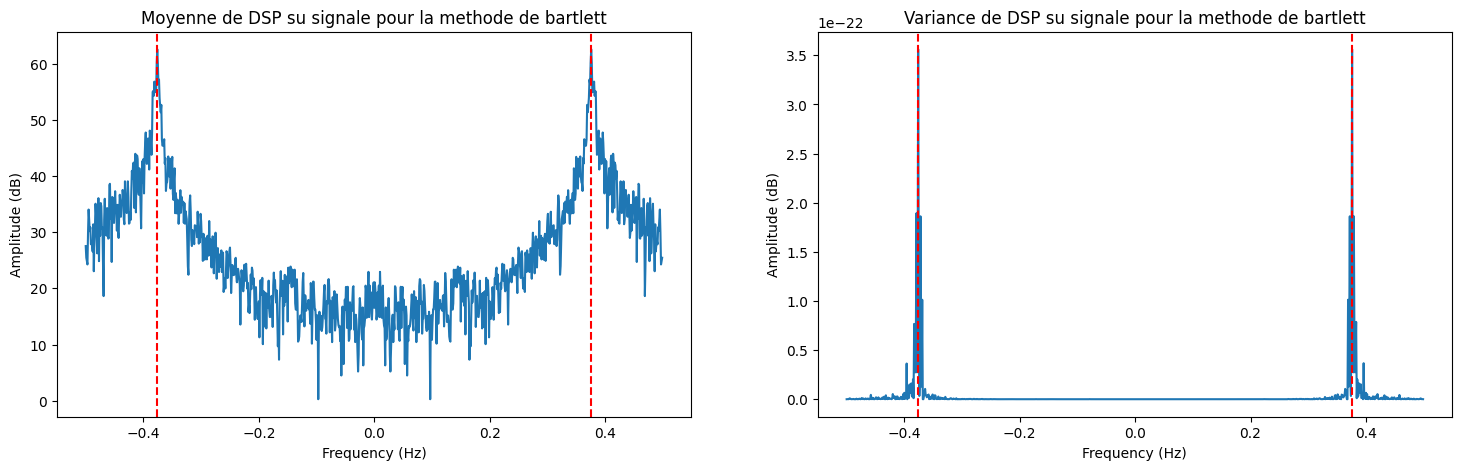

In [138]:
mean, var = mean_var(bartlett, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot((w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de bartlett")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.plot((w), var)
plt.title("Variance de DSP su signale pour la methode de bartlett")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


Text(0, 0.5, 'Amplitude (dB)')

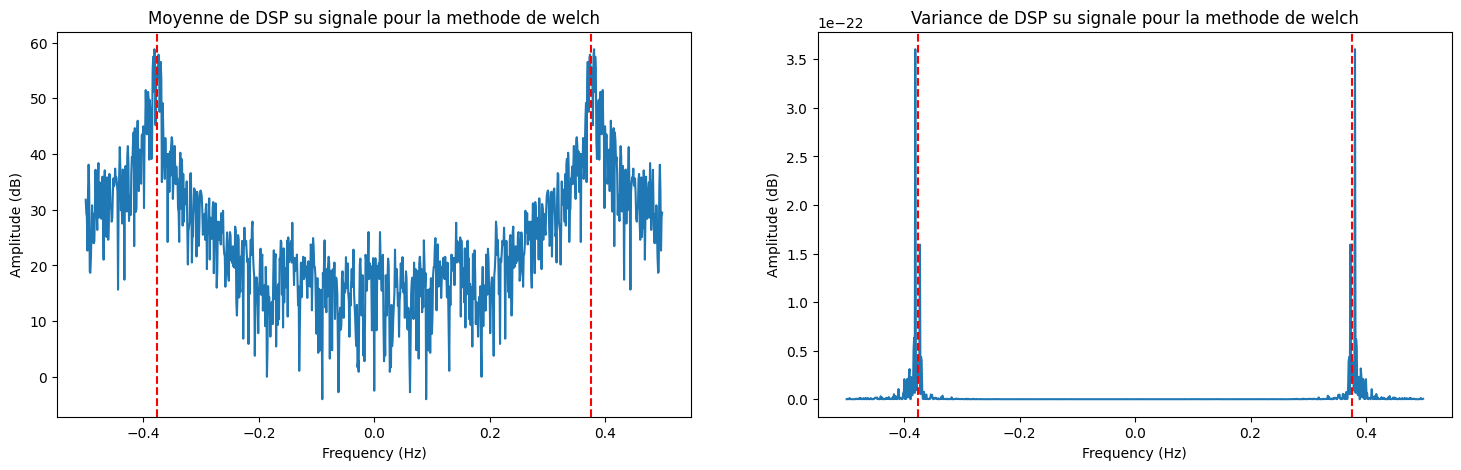

In [139]:
mean, var = mean_var(welch, signalb)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.plot((w), 20*np.log10(mean))
plt.title("Moyenne de DSP su signale pour la methode de welch")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

plt.subplot(1,2,2)
plt.plot((w), var)
plt.title("Variance de DSP su signale pour la methode de welch")
plt.axvline(x=peak_value_1, color='r', linestyle='--', linewidth=1.5)
plt.axvline(x=peak_value_2, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')


- décrire et analyser les résultats obtenus

- Effectuer une sythèse de vos commentaires sur les différentes méthodes utilisées.

## 2.4 Autre exemple 

Maintenant 

$$y(t)=\cos(2\pi f_1t)+\cos(2\pi f_2t)+\cos(2\pi f_3t)+b(t)$$

avec 
$f_1=0.01$ Hz, $f_2=0.02$ Hz, $f_3=0.06$ Hz et $b(t)$ et un bruit blanc gaussien


Estimer la DSP de $y(t)$ en utilisant les méthodes précédentes.

Commentaires

In [140]:
t = np.linspace(0,1, NbPoints)
f_1, f_2, f_3 = 0.01, 0.02, 0.06
sigma = 0.01
noise = np.random.uniform(0, sigma)
y = np.cos(2*np.pi*f_1*t) + np.cos(2*np.pi*f_2*t) + np.cos(2*np.pi*f_3*t) + noise

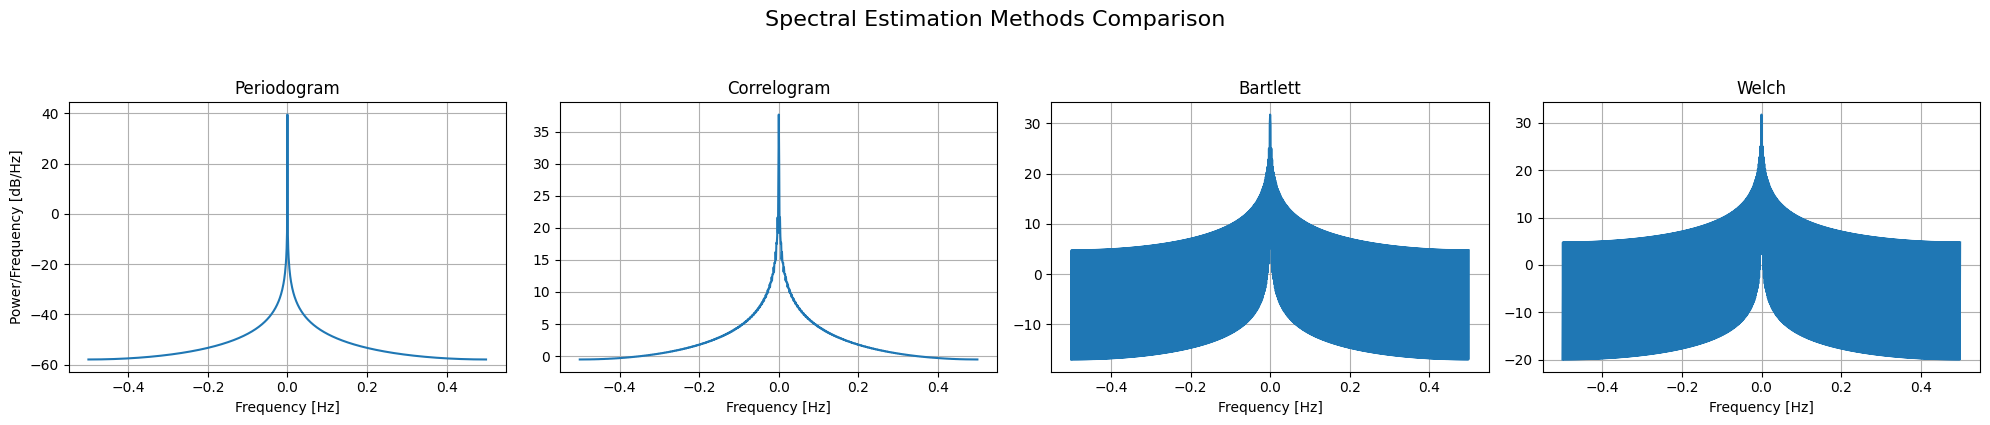

In [141]:
f, Pxx_den = Periodogram(y, fs)
w, corr = Correlogram(y, fs)
w, bartlett_dsp = bartlett(y)
w, welch_dsp = welch(y)

plt.figure(figsize=(20, 4))
plt.suptitle('Spectral Estimation Methods Comparison', fontsize=16, y=1.05)

plt.subplot(1, 4, 1)
plt.plot(f, 10*np.log10(Pxx_den))
plt.title('Periodogram')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power/Frequency [dB/Hz]')
plt.grid(True)

plt.subplot(1, 4, 2)
plt.plot((w), 10*np.log10(np.abs(corr)))
plt.title('Correlogram')
plt.xlabel('Frequency [Hz]')
plt.grid(True)

plt.subplot(1, 4, 3)
plt.plot((w), 10*np.log10((bartlett_dsp)))
plt.title('Bartlett')
plt.xlabel('Frequency [Hz]')
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot((w), 10*np.log10((welch_dsp)))
plt.title('Welch')
plt.xlabel('Frequency [Hz]')
plt.grid(True)

plt.tight_layout()
plt.show()


- décrire et analyser